In [6]:
import pandas as pd
import matplotlib.pyplot as plt

crime = pd.read_excel("incidents_2024_thru_mar2026.xlsx")
neighborhoods = pd.read_csv("neighborhoods.csv")

In [8]:
print(crime.columns)

Index(['Report_Number', 'ReportedDate', 'ReportedTime', 'Hour', 'DayofWeek',
       'ReportedMonth', 'NIBRS_Coded_Offense', 'NIBRS_Offense_Code',
       'NIBRS_Offense_Category', 'NIBRS_Offense_Type', 'NIBRS_Crime_Against',
       'NIBRS_Offense_Grouping', 'Violation', 'XCOORD', 'YCOORD', 'Zone',
       'Tract', 'Neighborhood', 'Block_Address'],
      dtype='object')


In [10]:
crime_counts = crime.groupby("Neighborhood").size().reset_index(name="crime_count")
crime_counts.head()

,Neighborhood,crime_count
0,Allegheny Center,683
1,Allegheny West,184
2,Allentown,1530
3,Arlington,436
4,Arlington Heights,157


In [12]:
merged = neighborhoods.merge(crime_counts, left_on="hood", right_on="Neighborhood", how="left")
merged["crime_count"] = merged["crime_count"].fillna(0)
merged.head()

,_id,objectid,fid_blockg,statefp10,countyfp10,tractce10,blkgrpce10,geoid10,namelsad10,mtfcc10,...,globalid,created_user,created_date,last_edited_user,last_edited_date,temp,shape_area,shape_length,Neighborhood,crime_count
0,12937,1,233,42,003,140500,3,420031405003,Block Group 3,G5030,...,a642a6b6-a2a9-48d5-acf2-3e2ce87d4bc0,SDE,2020-08-14T12:57:28,SDE,2020-08-14T13:02:13,NaN,8.417067e+06,14181.728584,Point Breeze North,608.0
1,12938,2,203,42,003,140100,3,420031401003,Block Group 3,G5030,...,20d4605b-258e-441a-a57e-a28fdabb6d30,SDE,2020-08-14T12:57:28,SDE,2020-08-14T13:02:41,NaN,3.410837e+07,30326.819418,Squirrel Hill North,780.0
2,12939,3,86,42,003,101700,2,420031017002,Block Group 2,G5030,...,bf4065e7-c29c-48bd-b529-e7fd99077238,SDE,2020-08-14T12:57:28,SDE,2020-08-14T12:59:55,NaN,1.275115e+07,14577.426328,Garfield,759.0
3,12940,4,214,42,003,050900,1,420030509001,Block Group 1,G5030,...,fed3fb32-0cd3-4556-aa41-17ee03b4fe41,SDE,2020-08-14T12:57:28,SDE,2020-08-14T12:58:41,NaN,4.897519e+06,13941.514356,Bedford Dwellings,825.0
4,12941,5,173,42,003,300100,5,420033001005,Block Group 5,G5030,...,8669d2f0-b886-4519-99d0-bb1015b592b0,SDE,2020-08-14T12:57:28,SDE,2020-08-14T13:00:19,NaN,8.353046e+06,12021.860516,Knoxville,1773.0


In [14]:
print(neighborhoods.columns)

Index(['_id', 'objectid', 'fid_blockg', 'statefp10', 'countyfp10', 'tractce10',
       'blkgrpce10', 'geoid10', 'namelsad10', 'mtfcc10', 'funcstat10',
       'aland10', 'awater10', 'intptlat10', 'intptlon10', 'shape_leng',
       'fid_neighb', 'pghdb_sde_neighborhood_2010_area', 'perimeter',
       'neighbor', 'neighbor_i', 'hood', 'hood_no', 'acres', 'sqmiles',
       'dpwdiv', 'unique_id', 'sectors', 'shape_le_1', 'shape_ar_1',
       'page_number', 'plannerassign', 'globalid', 'created_user',
       'created_date', 'last_edited_user', 'last_edited_date', 'temp',
       'shape_area', 'shape_length'],
      dtype='object')


In [16]:
merged["safety_score"] = 1 / (merged["crime_count"] + 1)

ranking = merged.sort_values(by="safety_score", ascending=False)
ranking[["hood", "crime_count", "safety_score"]].head(10)

,hood,crime_count,safety_score
67,Mt. Oliver,0.0,1.000000
50,Chartiers City,5.0,0.166667
73,St. Clair,12.0,0.076923
64,Ridgemont,40.0,0.024390
37,New Homestead,61.0,0.016129
82,Swisshelm Park,76.0,0.012987
28,East Carnegie,80.0,0.012346
76,Summer Hill,94.0,0.010526
69,Spring Hill-City View,103.0,0.009615
58,Esplen,104.0,0.009524


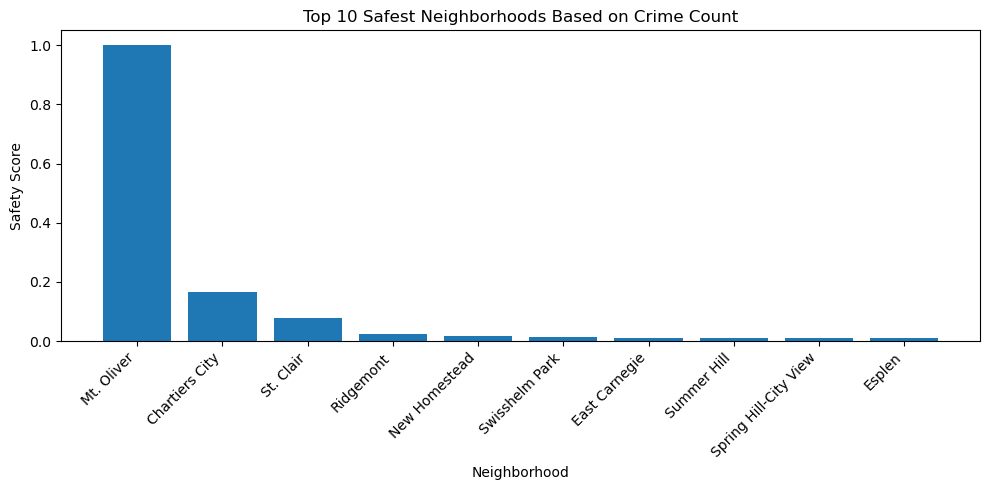

In [18]:
top10 = ranking[["hood", "crime_count", "safety_score"]].head(10)

plt.figure(figsize=(10,5))
plt.bar(top10["hood"], top10["safety_score"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Safest Neighborhoods Based on Crime Count")
plt.xlabel("Neighborhood")
plt.ylabel("Safety Score")
plt.tight_layout()
plt.show()

In [20]:
ranking = ranking[ranking["crime_count"] > 0]
ranking = ranking.sort_values(by="safety_score", ascending=False)
ranking[["hood", "crime_count", "safety_score"]].head(10)

,hood,crime_count,safety_score
50,Chartiers City,5.0,0.166667
73,St. Clair,12.0,0.076923
64,Ridgemont,40.0,0.024390
37,New Homestead,61.0,0.016129
82,Swisshelm Park,76.0,0.012987
28,East Carnegie,80.0,0.012346
76,Summer Hill,94.0,0.010526
69,Spring Hill-City View,103.0,0.009615
58,Esplen,104.0,0.009524
85,Regent Square,107.0,0.009259


This metric evaluates neighborhood safety by calculating a safety score based on crime counts. Neighborhoods with fewer reported crimes receive higher safety scores. The safety score is calculated as 1 divided by the crime count plus one, which ensures that neighborhoods with fewer crimes receive higher scores.

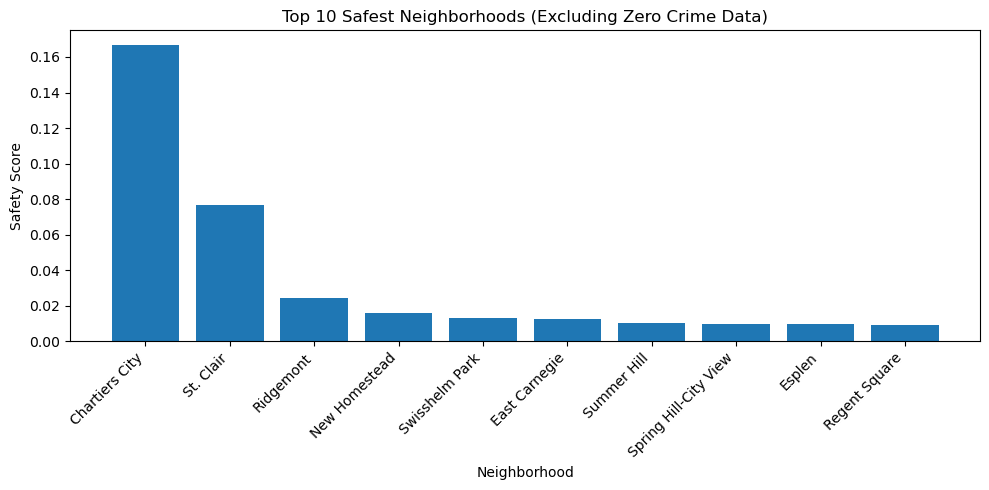

In [26]:
top10 = ranking[["hood", "crime_count", "safety_score"]].head(10)

plt.figure(figsize=(10,5))
plt.bar(top10["hood"], top10["safety_score"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Safest Neighborhoods (Excluding Zero Crime Data)")
plt.xlabel("Neighborhood")
plt.ylabel("Safety Score")
plt.tight_layout()
plt.show()

Based on this analysis, Chartiers City is the safest neighborhood because it has the lowest number of reported crimes among neighborhoods with recorded data.